In [8]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

### Exploratory Data Analysis

We will begin by loading the dataset into a dataframe and displaying the first 5 entries.

In [9]:
df = pd.read_csv("./Data/winequality-red-1.csv",sep=";|,",engine="python")
df.columns = df.columns.str.replace('"', '').str.strip() 
X = df.drop('quality',axis=1)
y = df['quality']
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


We will now get high level information from the dataset such as the features, null counts, datatypes, and dimension (rows and columns).

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


In [11]:
df.isnull().values.any() 

False

There are 1599 entries in the datset with 11 features and 1 target variable of quality. There are no null entries in the dataset.

In [12]:
df.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000
mean,8.319637,0.527821,0.270976,2.538806,0.087467,15.874922,46.467792,0.996747,3.311113,0.658149,10.422983,5.636023
std,1.741096,0.179060,0.194801,1.409928,0.047065,10.460157,32.895324,0.001887,0.154386,0.169507,1.065668,0.807569
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996750,3.310000,0.620000,10.200000,6.000000
75%,9.200000,0.640000,0.420000,2.600000,0.090000,21.000000,62.000000,0.997835,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


I will check the number of entries of each wine quality.

In [13]:
df["quality"].value_counts() 

quality
5    681
6    638
7    199
4     53
8     18
3     10
Name: count, dtype: int64

It looks like the classes are unbalanced so we must take this into account.

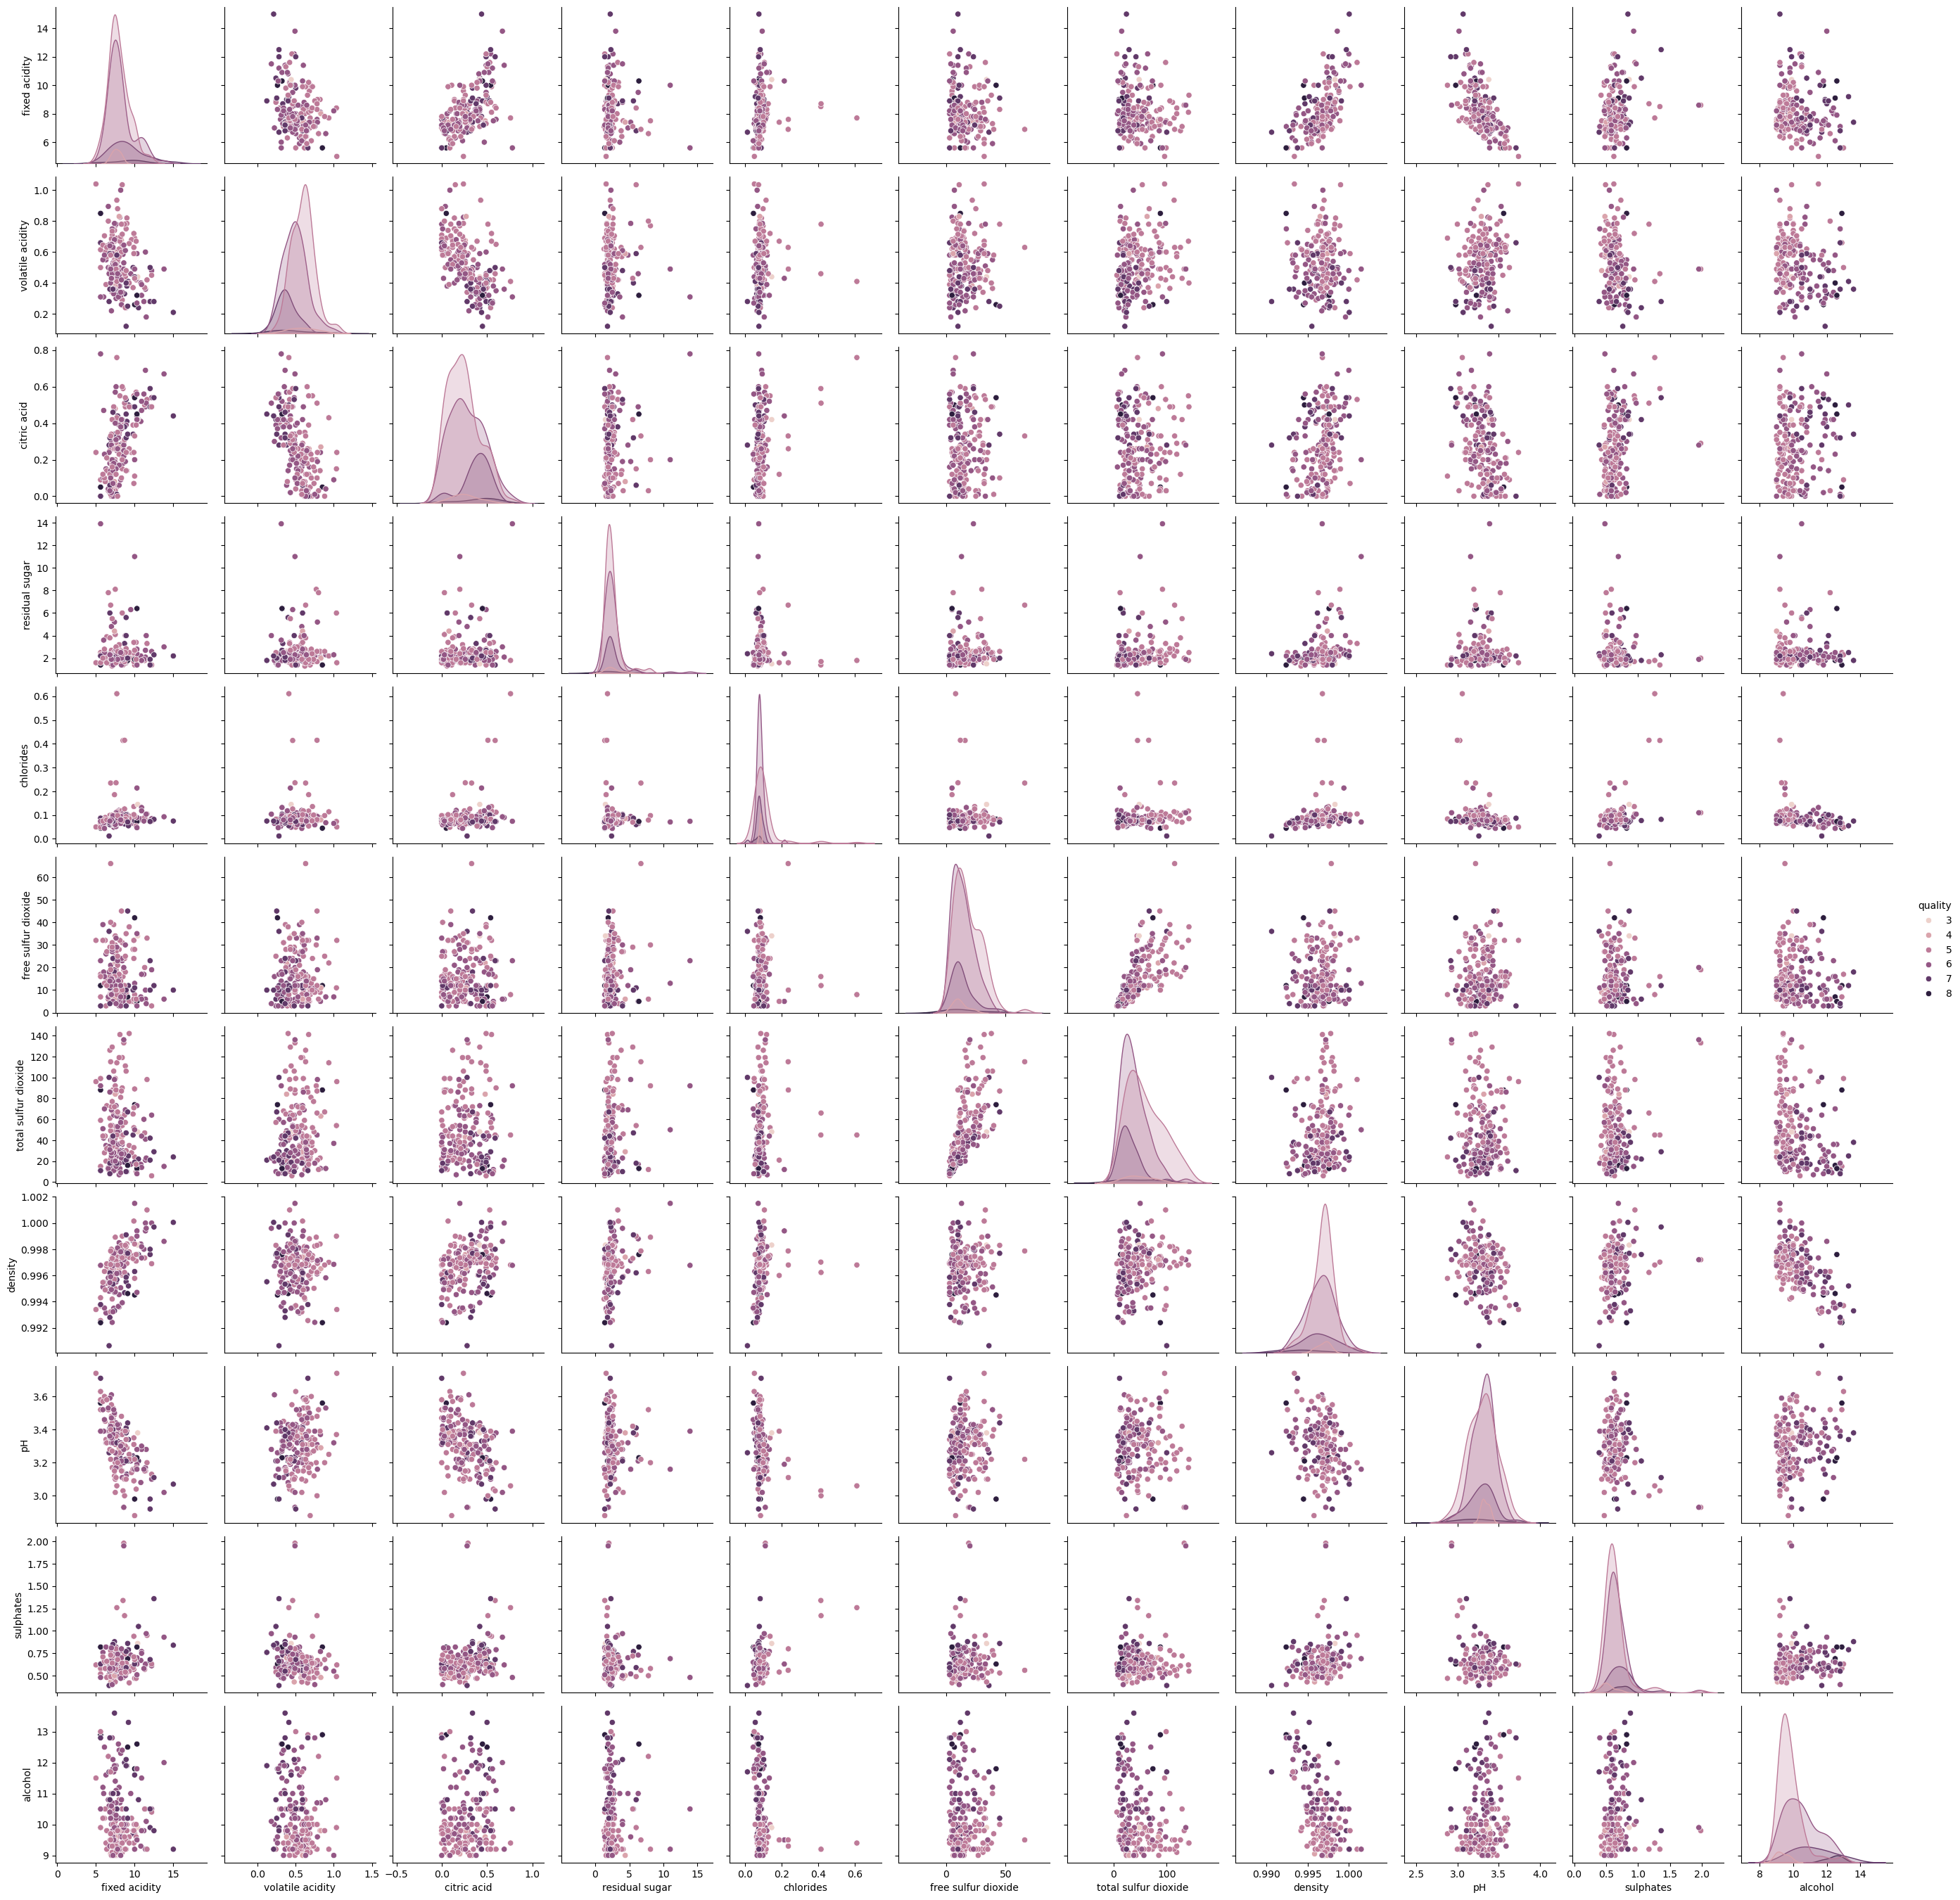

In [14]:
sns.pairplot(df.sample(200), hue="quality") 


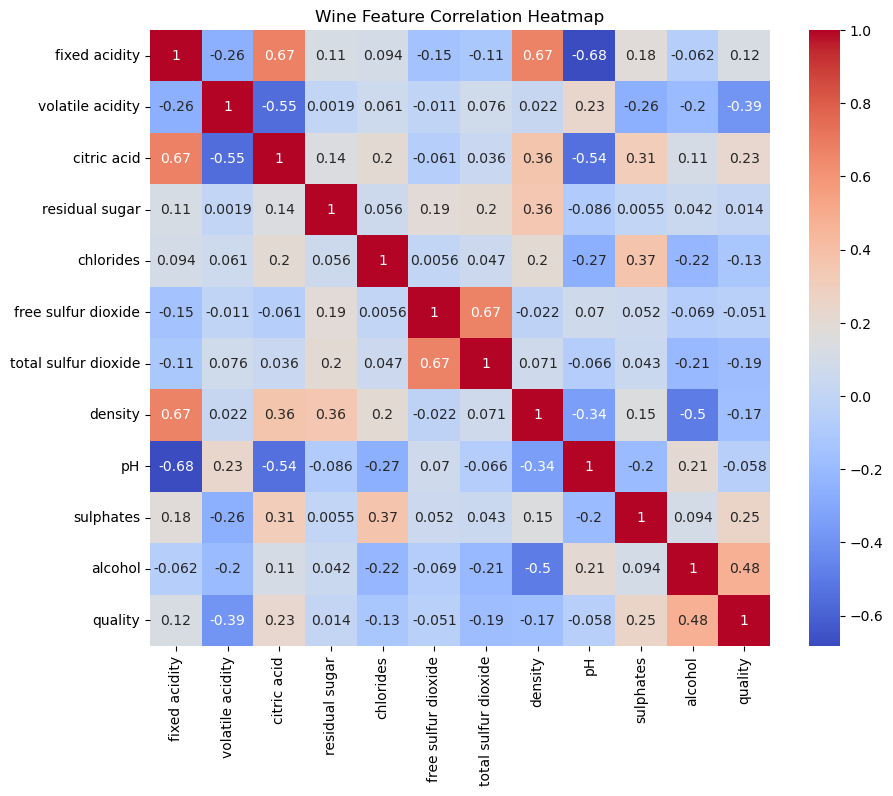

In [15]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), cmap="coolwarm", annot=True)
plt.title("Wine Feature Correlation Heatmap")
plt.show()


From the correlation heatmap it appears that fixed acidity has a moderately strong negative relationship with pH. Furthermore fixed acidity has a moderately strong positve relationship with citric acid. Additionally free sulfur dioxide has a moderately strong positive relationship with total sulfur diaoxide and density has a moderately strong positive relationship with fixed acidity. As for the relationshps between the features and target variable of wine quality, alcohol appears to have a moderate positive correlation with wine quality and volatile acidity appears to have a negative correlation with wine quality with the other features having quite weak correlations with wine quality. This suggests that the majority of relationships between the wine features and target quality is not strongly linear which suggests that more complex models maybe required to accurately capture the underlying patterns. 

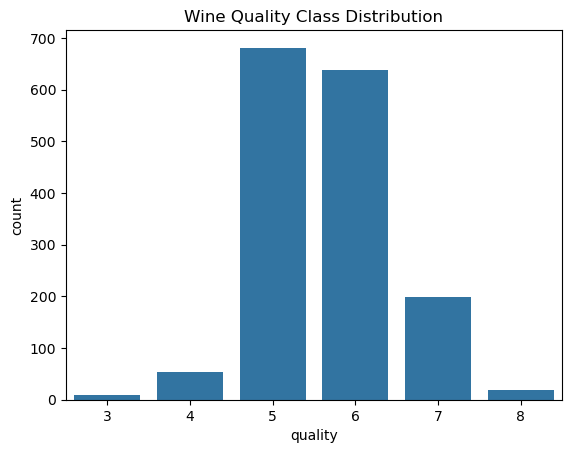

In [16]:
sns.countplot(x="quality", data=df)
plt.title("Wine Quality Class Distribution")
plt.show()

The distribution of the target variable class (wine quality) is imbalanced as the majority of wine samples are concentrated in quality of 5 and 6, and very few samples belong to the classes 3 and 8. 

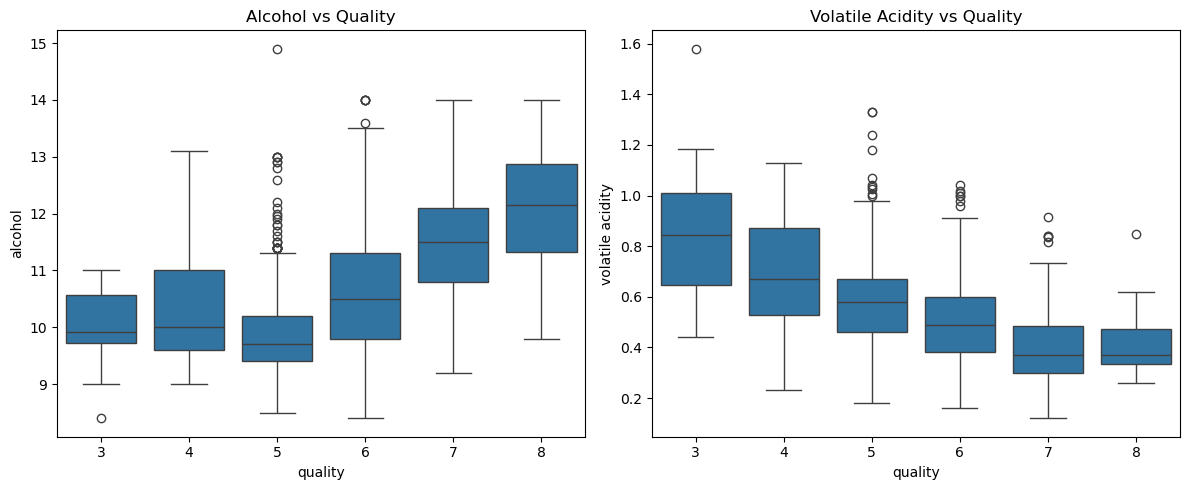

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12,5))

sns.boxplot(ax=axes[0], x="quality", y="alcohol", data=df)
axes[0].set_title("Alcohol vs Quality")

sns.boxplot(ax=axes[1], x="quality", y="volatile acidity", data=df)
axes[1].set_title("Volatile Acidity vs Quality")

plt.tight_layout()
plt.show()

From the correlation heatmap, alcohol and volatile acidity showed the strongest relationships with wine quality. To further examine these relationships, we analyze their distributions across different quality levels using boxplots. The results show that alcohol has a positive relationship with quality, while volatile acidity has a negative relationship with quality.

In [18]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42) #80/20 Split

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

Before tuning hyper parameters I will train and predict using a baseline random forest model.

In [19]:
random_forest_baseline = RandomForestClassifier(random_state=42)

random_forest_baseline.fit(X_train, y_train)
y_pred_baseline = random_forest_baseline.predict(X_test)

print("Baseline Accuracy:", accuracy_score(y_test, y_pred_baseline))
print("Baseline Weighted F1:", f1_score(y_test, y_pred_baseline, average="weighted"))
print(classification_report(y_test, y_pred_baseline))

Baseline Accuracy: 0.659375
Baseline Weighted F1: 0.6437864795480438
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         1
           4       0.00      0.00      0.00        10
           5       0.71      0.74      0.72       130
           6       0.63      0.70      0.66       132
           7       0.64      0.55      0.59        42
           8       0.00      0.00      0.00         5

    accuracy                           0.66       320
   macro avg       0.33      0.33      0.33       320
weighted avg       0.63      0.66      0.64       320



/Users/shangwenyota/anaconda3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/Users/shangwenyota/anaconda3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/Users/shangwenyota/anaconda3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


Now will perfrom grid search to find the best hyperparameters for the Random Forest Model.

In [20]:
rf = RandomForestClassifier(random_state=42)

param_grid = {
    "n_estimators": [100, 200, 250],
    "max_depth": [None, 5, 10, 20, 25],
    "min_samples_split": [2, 5, 8],
    "min_samples_leaf": [1, 2, 3],
    "class_weight": [None, "balanced"]
}
rf_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
grid_rf = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=rf_cv,
    scoring="f1_weighted",
    n_jobs=-1,
    verbose=1
)

grid_rf.fit(X_train, y_train)

print("Best Parameters:")
print(grid_rf.best_params_)

print("Best Cross-Validation F1 Score:")
print(grid_rf.best_score_)

Fitting 5 folds for each of 270 candidates, totalling 1350 fits
Best Parameters:
{'class_weight': 'balanced', 'max_depth': 25, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 200}
Best Cross-Validation F1 Score:
0.6814775252426761


In [21]:
best_rf = grid_rf.best_estimator_

y_pred_rf = best_rf.predict(X_test)

print("Tuned Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Tuned Random Forest Precision:", precision_score(y_test, y_pred_rf, average="weighted", zero_division=0))
print("Tuned Random Forest Recall:", recall_score(y_test, y_pred_rf, average="weighted", zero_division=0))
print("Tuned Random Forest F1:", f1_score(y_test, y_pred_rf, average="weighted", zero_division=0))

print(classification_report(y_test, y_pred_rf, zero_division=0))
print(confusion_matrix(y_test, y_pred_rf))

Tuned Random Forest Accuracy: 0.675
Tuned Random Forest Precision: 0.6424381868131868
Tuned Random Forest Recall: 0.675
Tuned Random Forest F1: 0.6579554738562091
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         1
           4       0.00      0.00      0.00        10
           5       0.71      0.77      0.74       130
           6       0.65      0.69      0.67       132
           7       0.64      0.60      0.62        42
           8       0.00      0.00      0.00         5

    accuracy                           0.68       320
   macro avg       0.33      0.34      0.34       320
weighted avg       0.64      0.68      0.66       320

[[  0   0   1   0   0   0]
 [  0   0   8   2   0   0]
 [  0   0 100  30   0   0]
 [  0   1  31  91   9   0]
 [  0   0   0  17  25   0]
 [  0   0   0   0   5   0]]


### Artificial Neural Network (ANN)

Now I will train and evaluate an Artificial Neural Network model using scikit-learn's MLPClassifier.

First, I will train a baseline ANN model to establish a baseline performance.

In [22]:
ann_baseline = MLPClassifier(hidden_layer_sizes=(50,), activation="relu", max_iter=1000, random_state=42)

ann_baseline.fit(X_train, y_train)
y_pred_ann_baseline = ann_baseline.predict(X_test)

print("Baseline ANN Accuracy:", accuracy_score(y_test, y_pred_ann_baseline))
print("Baseline ANN Precision:", precision_score(y_test, y_pred_ann_baseline, average="weighted", zero_division=0))
print("Baseline ANN Recall:", recall_score(y_test, y_pred_ann_baseline, average="weighted", zero_division=0))
print("Baseline ANN F1:", f1_score(y_test, y_pred_ann_baseline, average="weighted", zero_division=0))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_ann_baseline, zero_division=0))

Baseline ANN Accuracy: 0.60625
Baseline ANN Precision: 0.5885826391274477
Baseline ANN Recall: 0.60625
Baseline ANN F1: 0.5958716430849449

Classification Report:
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         1
           4       0.25      0.10      0.14        10
           5       0.64      0.70      0.67       130
           6       0.61      0.61      0.61       132
           7       0.54      0.52      0.53        42
           8       0.00      0.00      0.00         5

    accuracy                           0.61       320
   macro avg       0.34      0.32      0.32       320
weighted avg       0.59      0.61      0.60       320



/Users/shangwenyota/anaconda3/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:686: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


Now I will perform a grid search to find the best hyperparameters for the ANN model.

In [23]:
ann = MLPClassifier(max_iter=1000, random_state=42)

param_grid_ann = {
    "hidden_layer_sizes": [(50,), (100,), (50, 50), (100, 50)],
    "activation": ["relu", "tanh"],
    "alpha": [0.0001, 0.001, 0.01],
    "learning_rate_init": [0.001, 0.01]
}

ann_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
grid_ann = GridSearchCV(
    estimator=ann,
    param_grid=param_grid_ann,
    cv=ann_cv,
    scoring="f1_weighted",
    n_jobs=-1,
    verbose=1
)

grid_ann.fit(X_train, y_train)

print("Best Parameters:")
print(grid_ann.best_params_)

print("Best Cross-Validation F1 Score:")
print(grid_ann.best_score_)

Fitting 5 folds for each of 48 candidates, totalling 240 fits


/Users/shangwenyota/anaconda3/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:686: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/Users/shangwenyota/anaconda3/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:686: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/Users/shangwenyota/anaconda3/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:686: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/Users/shangwenyota/anaconda3/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:686: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/Use

Best Parameters:
{'activation': 'relu', 'alpha': 0.001, 'hidden_layer_sizes': (100, 50), 'learning_rate_init': 0.001}
Best Cross-Validation F1 Score:
0.6375693529737909


In [24]:
best_ann = grid_ann.best_estimator_

y_pred_ann = best_ann.predict(X_test)

print("Tuned ANN Accuracy:", accuracy_score(y_test, y_pred_ann))
print("Tuned ANN Precision:", precision_score(y_test, y_pred_ann, average="weighted", zero_division=0))
print("Tuned ANN Recall:", recall_score(y_test, y_pred_ann, average="weighted", zero_division=0))
print("Tuned ANN F1:", f1_score(y_test, y_pred_ann, average="weighted", zero_division=0))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_ann, zero_division=0))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_ann))

Tuned ANN Accuracy: 0.64375
Tuned ANN Precision: 0.6302257653061225
Tuned ANN Recall: 0.64375
Tuned ANN F1: 0.6350857278395229

Classification Report:
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         1
           4       0.25      0.10      0.14        10
           5       0.71      0.68      0.70       130
           6       0.63      0.70      0.66       132
           7       0.57      0.57      0.57        42
           8       0.00      0.00      0.00         5

    accuracy                           0.64       320
   macro avg       0.36      0.34      0.35       320
weighted avg       0.63      0.64      0.64       320


Confusion Matrix:
[[ 0  0  1  0  0  0]
 [ 0  1  3  6  0  0]
 [ 0  2 89 35  4  0]
 [ 0  1 29 92 10  0]
 [ 0  0  3 13 24  2]
 [ 0  0  0  1  4  0]]


Visualizations for the ANN model:

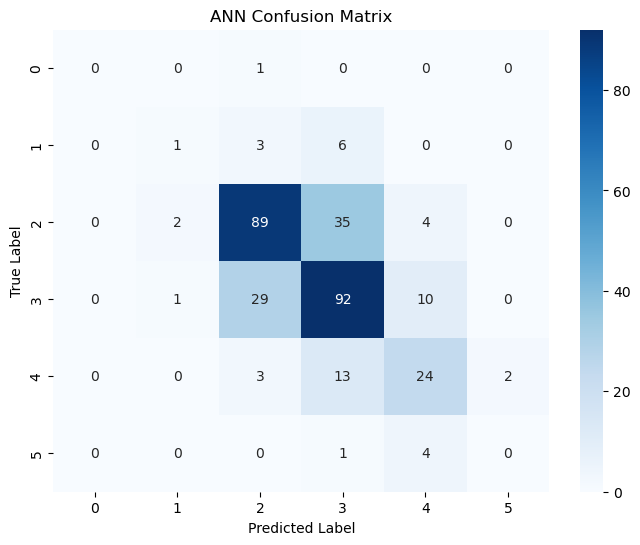

In [25]:
cm_ann = confusion_matrix(y_test, y_pred_ann)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_ann, annot=True, fmt='d', cmap='Blues', cbar=True)
plt.title('ANN Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

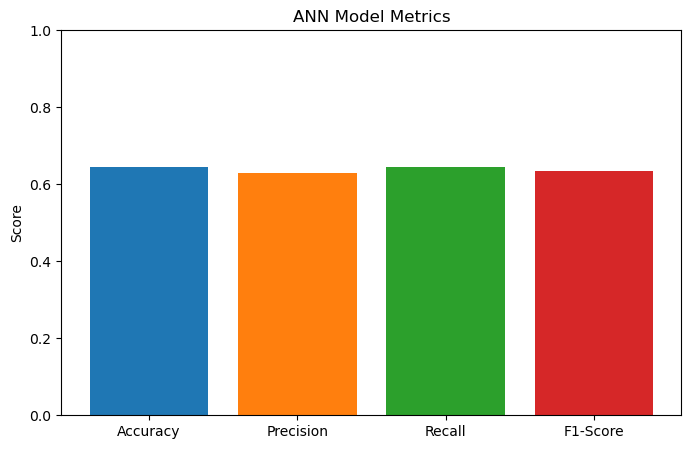

In [26]:
ann_metrics = {
    'Accuracy': accuracy_score(y_test, y_pred_ann),
    'Precision': precision_score(y_test, y_pred_ann, average="weighted", zero_division=0),
    'Recall': recall_score(y_test, y_pred_ann, average="weighted", zero_division=0),
    'F1-Score': f1_score(y_test, y_pred_ann, average="weighted", zero_division=0)
}

plt.figure(figsize=(8, 5))
plt.bar(ann_metrics.keys(), ann_metrics.values(), color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'])
plt.title('ANN Model Metrics')
plt.ylabel('Score')
plt.ylim([0, 1])
plt.show()

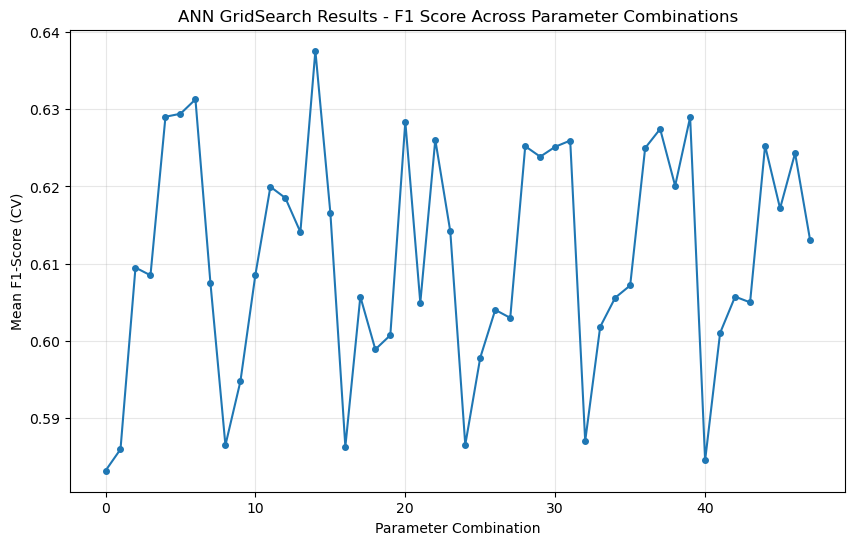

In [27]:
grid_results_ann = pd.DataFrame(grid_ann.cv_results_)

plt.figure(figsize=(10, 6))
plt.plot(range(len(grid_results_ann)), grid_results_ann['mean_test_score'], marker='o', linestyle='-', markersize=4)
plt.xlabel('Parameter Combination')
plt.ylabel('Mean F1-Score (CV)')
plt.title('ANN GridSearch Results - F1 Score Across Parameter Combinations')
plt.grid(True, alpha=0.3)
plt.show()